<a href="https://colab.research.google.com/github/nayan777pratyush/Heart-Related-Study/blob/main/R23EF192_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print('Running in Colab:' if IN_COLAB else 'Running in local Jupyter')

if IN_COLAB:
    from google.colab import files
    print('Please upload your heart.csv file when prompted (choose the Kaggle heart.csv).')
    uploaded = files.upload()
    for fname in uploaded:
        print('Uploaded file:', fname)
else:
    if os.path.exists('heart.csv'):
        print("Found 'heart.csv' in current directory.")
    else:
        print("No 'heart.csv' found in current directory. Please upload or place heart.csv here and rerun.")

DATA_FILENAME = 'heart.csv'
if not os.path.exists(DATA_FILENAME):
    print('\nWARNING: heart.csv not found in the current directory. Upload or place the file and re-run the cell.')
else:
    print('\nheart.csv is available. Proceed with running the notebook.')


Running in Colab:
Please upload your heart.csv file when prompted (choose the Kaggle heart.csv).


Saving heart.csv to heart.csv
Uploaded file: heart.csv

heart.csv is available. Proceed with running the notebook.


In [ ]:
# Imports and plotting style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9,6)

print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
# Load the dataset
df = pd.read_csv("heart.csv")

# Print the entire dataset
print("🩺 Full contents of heart.csv:\n")
print(df.to_string(index=False))   # prints all rows and columns

# Print the shape
print(f"\nShape of dataset: {df.shape}")

🩺 Full contents of heart.csv:

 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
  52    1   0       125   212    0        1      168      0      1.0      2   2     3       0
  53    1   0       140   203    1        0      155      1      3.1      0   0     3       0
  70    1   0       145   174    0        1      125      1      2.6      0   0     3       0
  61    1   0       148   203    0        1      161      0      0.0      2   1     3       0
  62    0   0       138   294    1        1      106      0      1.9      1   3     2       0
  58    0   0       100   248    0        0      122      0      1.0      1   0     2       1
  58    1   0       114   318    0        2      140      0      4.4      0   3     1       0
  55    1   0       160   289    0        0      145      1      0.8      1   1     3       0
  46    1   0       120   249    0        0      144      0      0.8      2   0     3       0
  54    1   0       122   286

In [ ]:
# Load dataset (expects 'heart.csv' in the working dir)
DATA_PATH = 'heart.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("heart.csv not found. Upload it (Colab: use upload cell) or place in notebook folder.")

df = pd.read_csv(DATA_PATH)
print('Loaded dataset:', DATA_PATH, '-> shape:', df.shape)
df.head()


Loaded dataset: heart.csv -> shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


from matplotlib import pyplot as plt
_df_0['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['sex'].plot(kind='hist', bins=20, title='sex')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['trestbps'].plot(kind='hist', bins=20, title='trestbps')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['cp']
  ys = series['chol']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('cp', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('cp')
_ = plt.ylabel('chol')

from matplotlib import pyplot as plt
_df_12['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['sex'].plot(kind='line', figsize=(8, 4), title='sex')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['trestbps'].plot(kind='line', figsize=(8, 4), title='trestbps')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['chol'].plot(kind='line', figsize=(8, 4), title='chol')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Initial inspection
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nInfo:')
df.info()
print('\nMissing values per column:')
print(df.isna().sum())
print('\nBasic stats:')
df.describe(include='all').T


Shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing values per column:
age         0
sex         0
cp

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


from matplotlib import pyplot as plt
_df_16['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_17['std'].plot(kind='hist', bins=20, title='std')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_18['min'].plot(kind='hist', bins=20, title='min')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['count']
  ys = series['25%']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_27.sort_values('count', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('count')
_ = plt.ylabel('25%')

from matplotlib import pyplot as plt
_df_28['mean'].plot(kind='line', figsize=(8, 4), title='mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_29['std'].plot(kind='line', figsize=(8, 4), title='std')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_30['min'].plot(kind='line', figsize=(8, 4), title='min')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_31['25%'].plot(kind='line', figsize=(8, 4), title='25%')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Preprocessing :
import warnings
warnings.filterwarnings('ignore')

data = df.copy()
steps = []

# 1. Standardize column names
data.columns = [c.strip().lower() for c in data.columns]
steps.append('standardize column names')

# 2. Remove duplicates
before = len(data)
data = data.drop_duplicates()
steps.append(f'removed duplicates: {before - len(data)}')

# 3. Impute numeric missing values (median)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if data[num_cols].isna().sum().sum() > 0:
    imputer = SimpleImputer(strategy='median')
    data[num_cols] = imputer.fit_transform(data[num_cols])
    steps.append('imputed numeric missing values (median)')
else:
    steps.append('no numeric missing values')

# 4. Fill categorical missing with mode
cat_cols = [c for c in data.columns if c not in num_cols]
for c in cat_cols:
    if data[c].isna().sum() > 0:
        data[c].fillna(data[c].mode()[0], inplace=True)
        steps.append(f'imputed mode for {c}')

# 5. Convert int-coded cols to category
for c in ['sex','cp','fbs','restecg','exang','slope','ca','thal']:
    if c in data.columns:
        data[c] = data[c].astype('category')
steps.append('converted common int-coded features to category dtype')

# 6. Create derived features
data['age_bin'] = pd.cut(data['age'], bins=[0,35,50,65,120], labels=['young','adult','mid','senior'])
steps.append('created age_bin')
if 'chol' in data.columns:
    data['chol_per_age'] = data['chol'] / (data['age'] + 1)
    steps.append('created chol_per_age')

# 7. Winsorize continuous columns
def winsorize(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return s.clip(low, high)
for c in ['trestbps','chol','thalach']:
    if c in data.columns:
        data[c] = winsorize(data[c])
steps.append('winsorized trestbps, chol, thalach where present')

# 8. Encode target
if data['target'].dtype.name == 'category' or data['target'].dtype == object:
    data['target'] = LabelEncoder().fit_transform(data['target'].astype(str))
steps.append('encoded target to numeric if needed')

# 9. One-hot encode categorical predictors
cat_for_ohe = [c for c in data.columns if str(data[c].dtype)=='category' and c not in ['target','age_bin']]
if len(cat_for_ohe) > 0:
    data = pd.get_dummies(data, columns=cat_for_ohe, drop_first=True)
steps.append('one-hot encoded categorical predictors')

# 10. Scale numeric features
num_feats = [c for c in data.columns if c not in ['target','age_bin'] and data[c].dtype in [np.float64, np.int64]]
scaler = StandardScaler()
if len(num_feats) > 0:
    data[num_feats] = scaler.fit_transform(data[num_feats])
    steps.append('scaled numeric features with StandardScaler')

# 11. Interaction feature
if 'age' in data.columns and 'chol' in data.columns:
    data['age_x_chol'] = (data['age'] * data['chol'])
    steps.append('created interaction feature age_x_chol')

# 12. Train-test split
X = data.drop(['target','age_bin'], axis=1)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
steps.append('train-test split (80/20 stratified)')

print('Preprocessing steps applied:')
for s in steps:
    print('-', s)
print('\nFinal shapes: X_train', X_train.shape, 'X_test', X_test.shape)
print('\nTop correlations with target (original df numerics):')
print(df.corr()['target'].abs().sort_values(ascending=False).head(10))


Preprocessing steps applied:
- standardize column names
- removed duplicates: 723
- no numeric missing values
- converted common int-coded features to category dtype
- created age_bin
- created chol_per_age
- winsorized trestbps, chol, thalach where present
- encoded target to numeric if needed
- one-hot encoded categorical predictors
- scaled numeric features with StandardScaler
- created interaction feature age_x_chol
- train-test split (80/20 stratified)

Final shapes: X_train (241, 24) X_test (61, 24)

Top correlations with target (original df numerics):
target     1.000000
oldpeak    0.438441
exang      0.438029
cp         0.434854
thalach    0.422895
ca         0.382085
slope      0.345512
thal       0.337838
sex        0.279501
age        0.229324
Name: target, dtype: float64


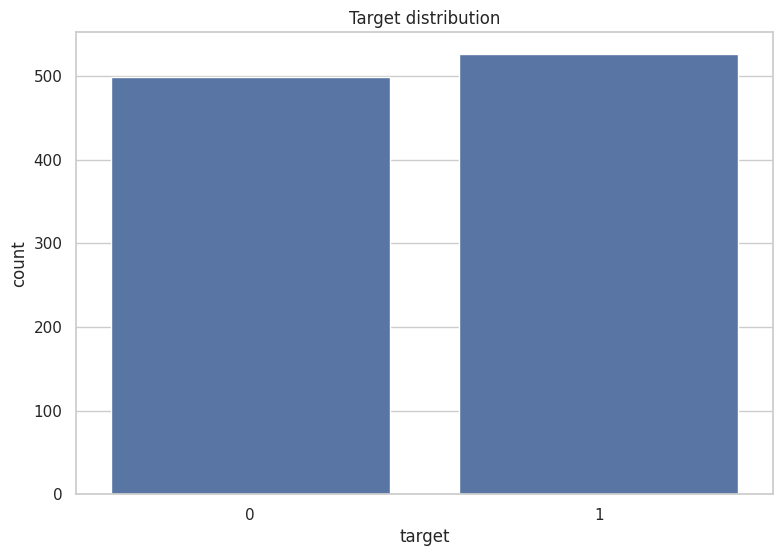

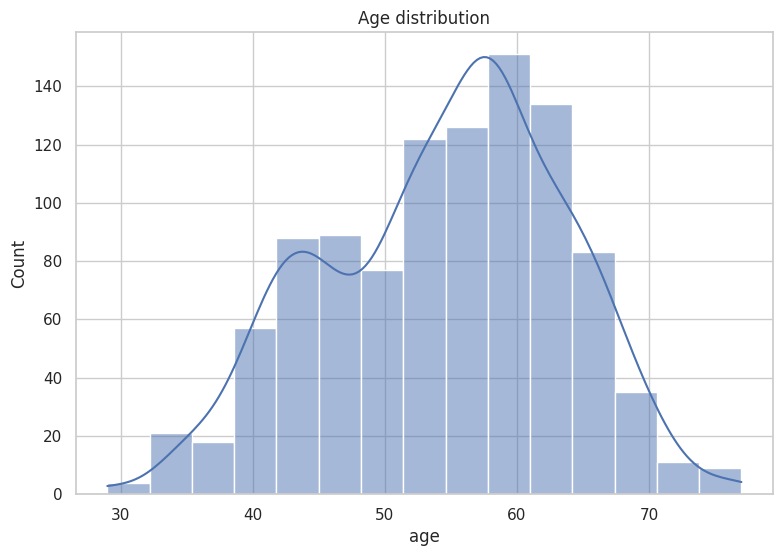

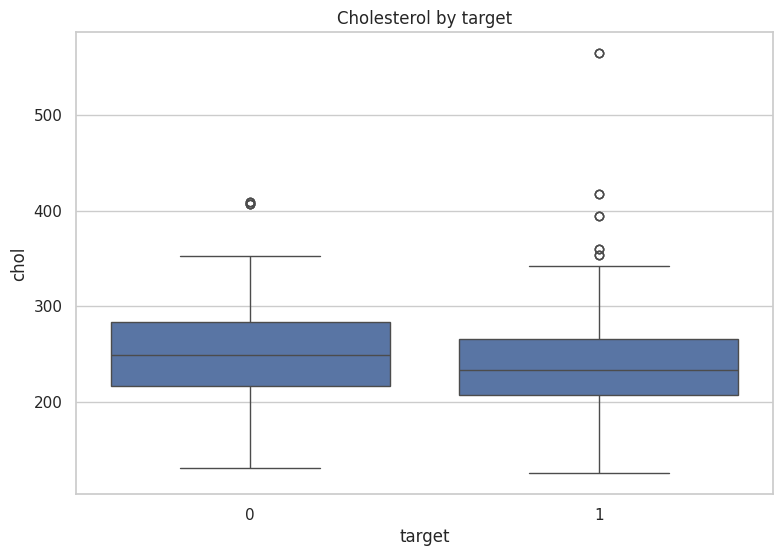

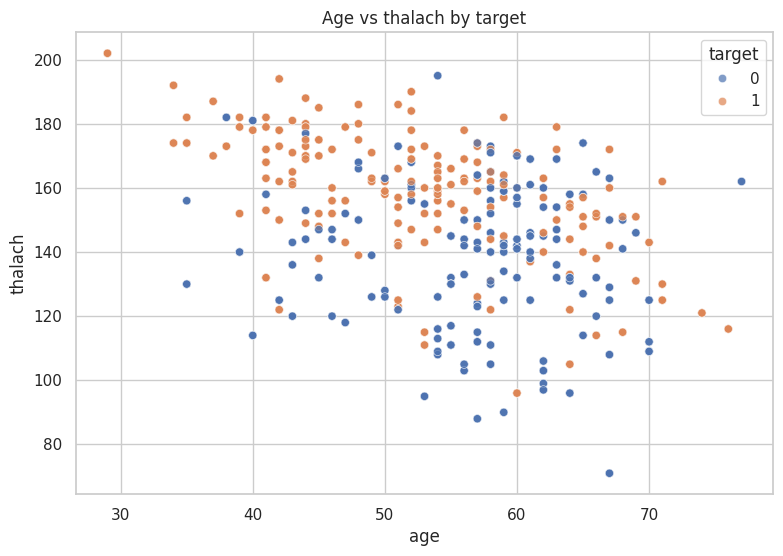

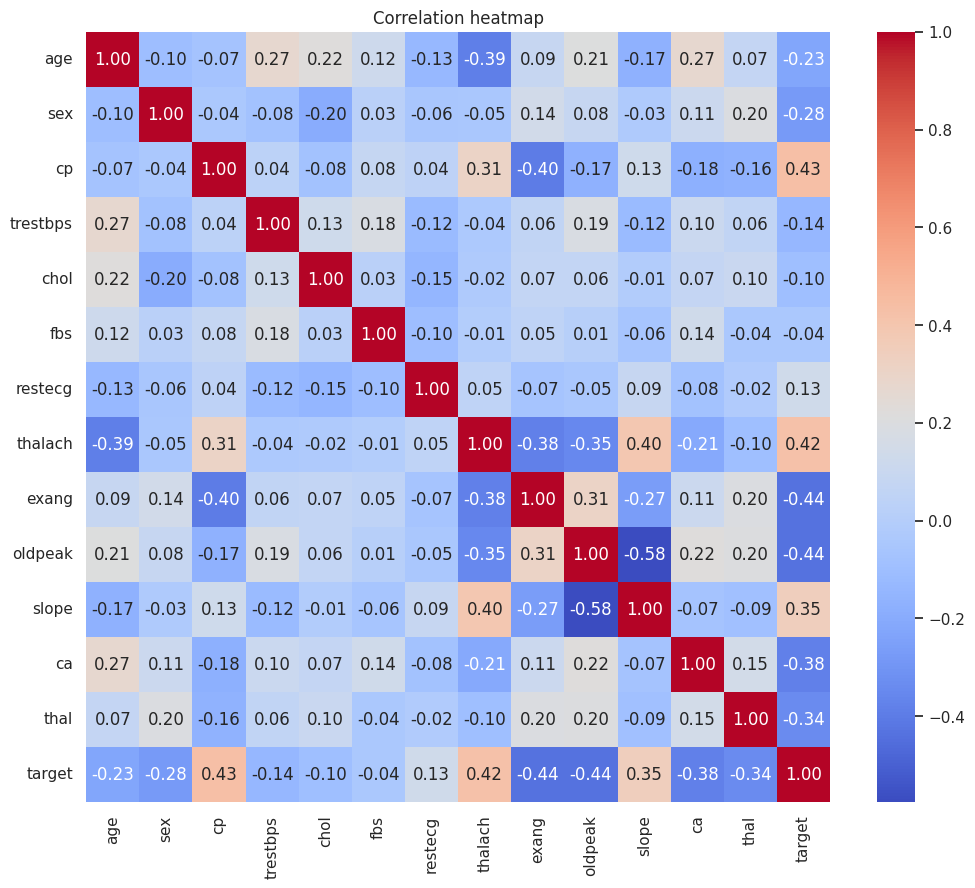

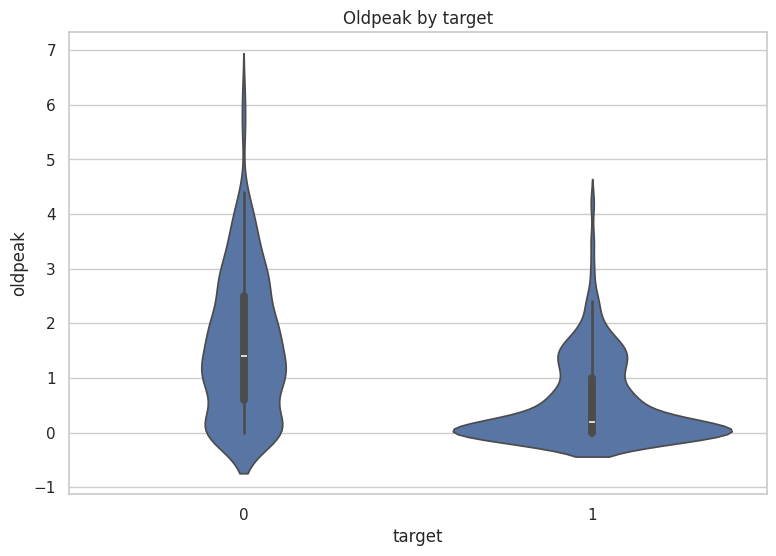

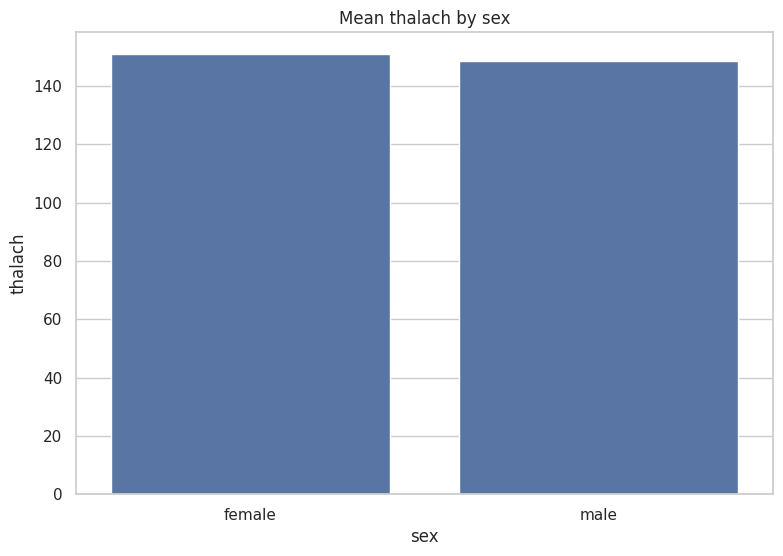

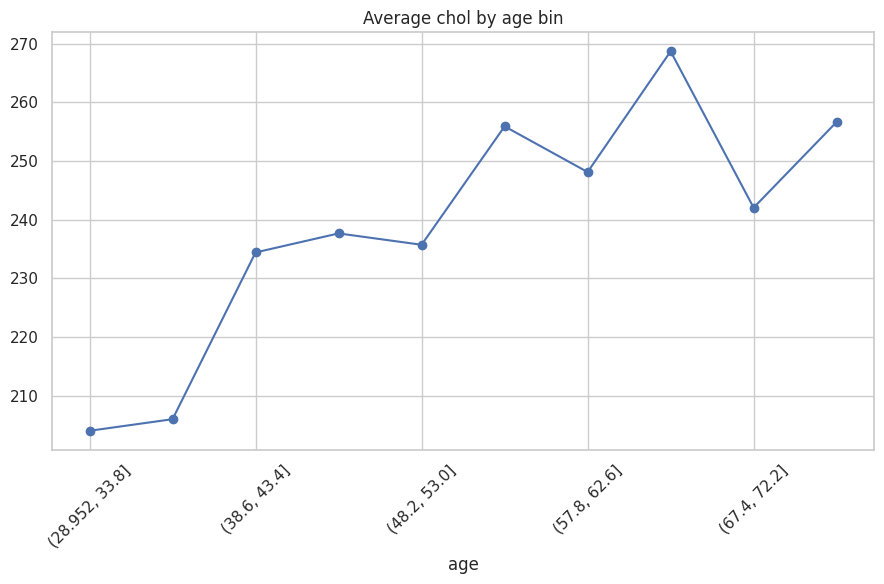

<Figure size 900x600 with 0 Axes>

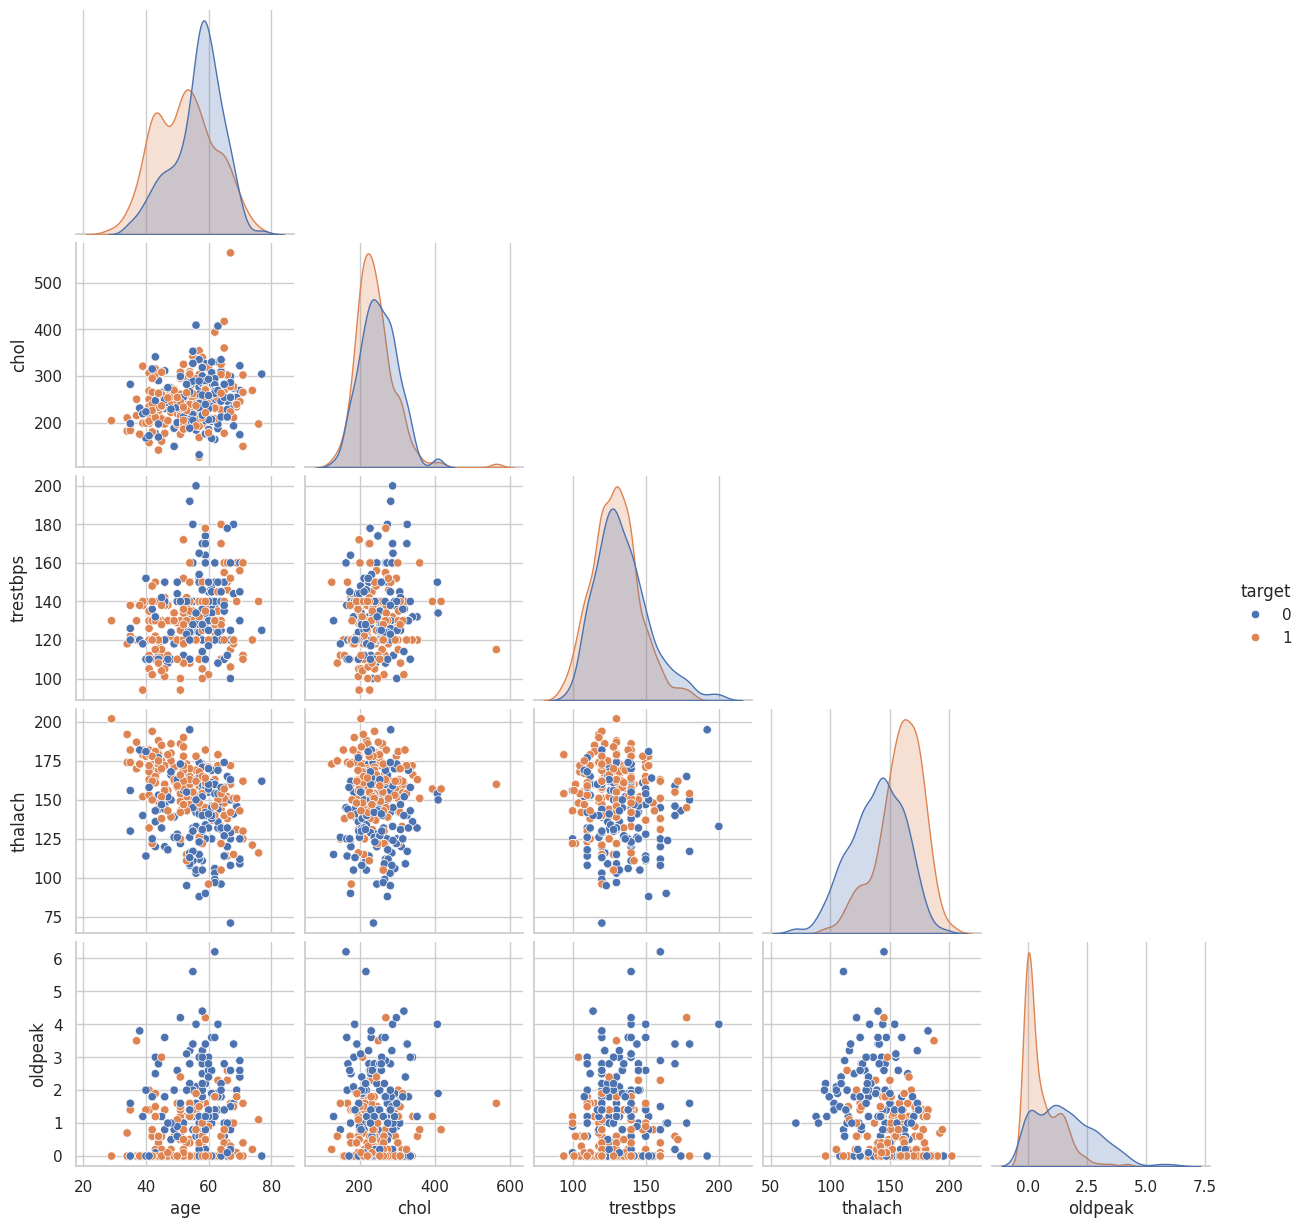

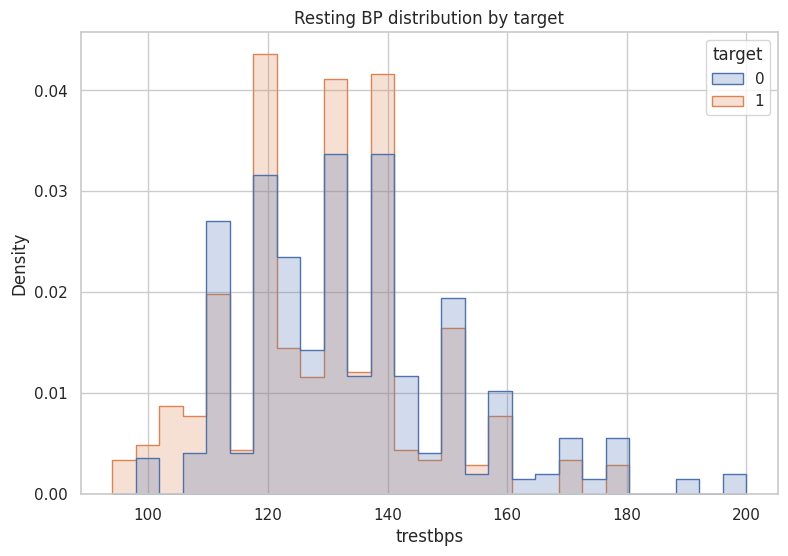

<Figure size 900x600 with 0 Axes>

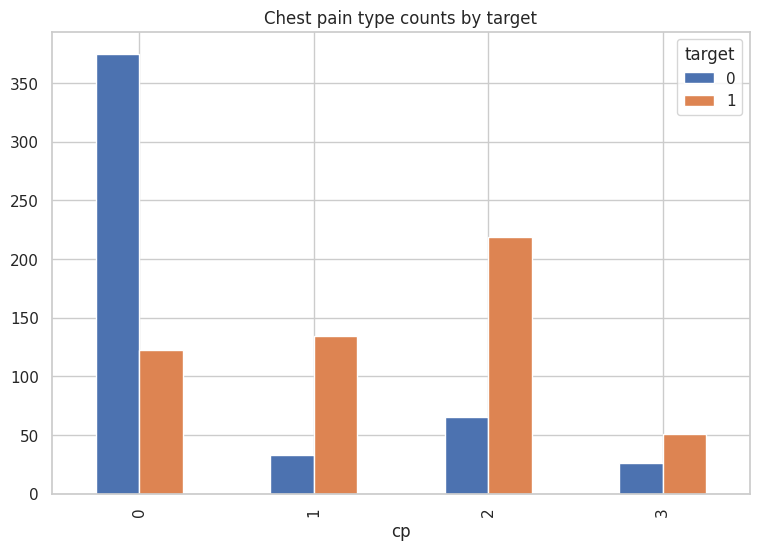

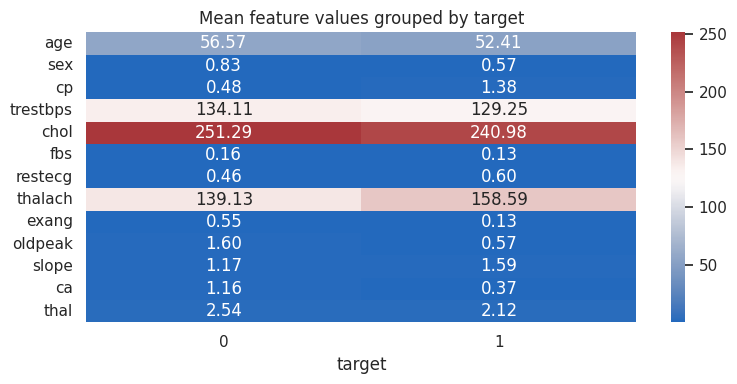

Saved plots to ./plots


In [ ]:
# Visualizations (>=12) saved to ./plots
os.makedirs('plots', exist_ok=True)
orig = df.copy()

plt.figure()
sns.countplot(x='target', data=orig)
plt.title('Target distribution')
plt.savefig('plots/plot1_target_count.png')
plt.show()

plt.figure()
sns.histplot(orig['age'], kde=True, bins=15)
plt.title('Age distribution')
plt.savefig('plots/plot2_age_hist.png')
plt.show()

plt.figure()
sns.boxplot(x='target', y='chol', data=orig)
plt.title('Cholesterol by target')
plt.savefig('plots/plot3_chol_box.png')
plt.show()

plt.figure()
sns.scatterplot(data=orig, x='age', y='thalach', hue='target', alpha=0.7)
plt.title('Age vs thalach by target')
plt.savefig('plots/plot4_age_thalach.png')
plt.show()

plt.figure(figsize=(12,10))
num = orig.select_dtypes(include=[np.number])
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.savefig('plots/plot5_corr.png')
plt.show()

plt.figure()
sns.violinplot(x='target', y='oldpeak', data=orig)
plt.title('Oldpeak by target')
plt.savefig('plots/plot6_oldpeak_violin.png')
plt.show()

plt.figure()
mean_th = orig.groupby('sex')['thalach'].mean().reset_index()
mean_th['sex'] = mean_th['sex'].map({0:'female',1:'male'})
sns.barplot(x='sex', y='thalach', data=mean_th)
plt.title('Mean thalach by sex')
plt.savefig('plots/plot7_mean_thalach_sex.png')
plt.show()

plt.figure()
avg_ch = orig.groupby(pd.cut(orig['age'], bins=10))['chol'].mean()
avg_ch.plot(marker='o')
plt.title('Average chol by age bin')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/plot8_avg_chol_agebin.png')
plt.show()

plt.figure()
cols = ['age','chol','trestbps','thalach','oldpeak']
sns.pairplot(orig[cols + ['target']], hue='target', diag_kind='kde', corner=True)
plt.savefig('plots/plot9_pairplot.png')
plt.show()

plt.figure()
sns.histplot(data=orig, x='trestbps', hue='target', element='step', stat='density', common_norm=False)
plt.title('Resting BP distribution by target')
plt.savefig('plots/plot10_trestbps.png')
plt.show()

plt.figure()
ct = pd.crosstab(orig['cp'], orig['target'])
ct.plot(kind='bar')
plt.title('Chest pain type counts by target')
plt.savefig('plots/plot11_cp_counts.png')
plt.show()

plt.figure(figsize=(8,4))
mbt = orig.groupby('target').mean().T
sns.heatmap(mbt, annot=True, fmt='.2f', cmap='vlag')
plt.title('Mean feature values grouped by target')
plt.tight_layout()
plt.savefig('plots/plot12_mean_by_target.png')
plt.show()

print('Saved plots to ./plots')


Saved model results to ./model_results.csv


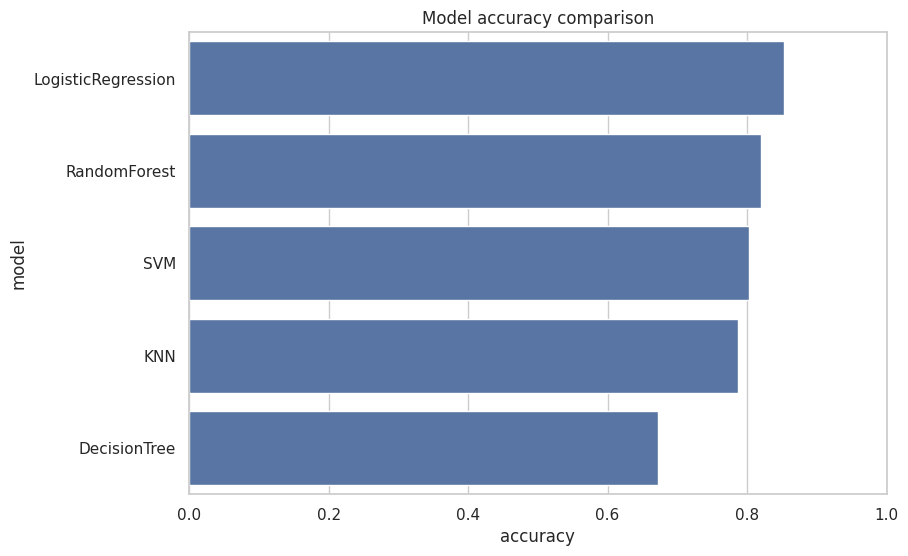

Saved confusion matrices to ./plots


In [ ]:
# Machine Learning: train & evaluate models
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append({'model':name, 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1})

res_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
res_df.to_csv('model_results.csv', index=False)
print('Saved model results to ./model_results.csv')
res_df

plt.figure()
sns.barplot(x='accuracy', y='model', data=res_df, orient='h')
plt.xlim(0,1)
plt.title('Model accuracy comparison')
plt.savefig('plots/model_accuracy_comparison.png')
plt.show()

for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix: {name}')
    plt.xlabel('predicted')
    plt.ylabel('actual')
    plt.savefig(f'plots/cm_{name}.png')
    plt.close()

print('Saved confusion matrices to ./plots')


🖼️ Displaying 18 plots from: ./plots



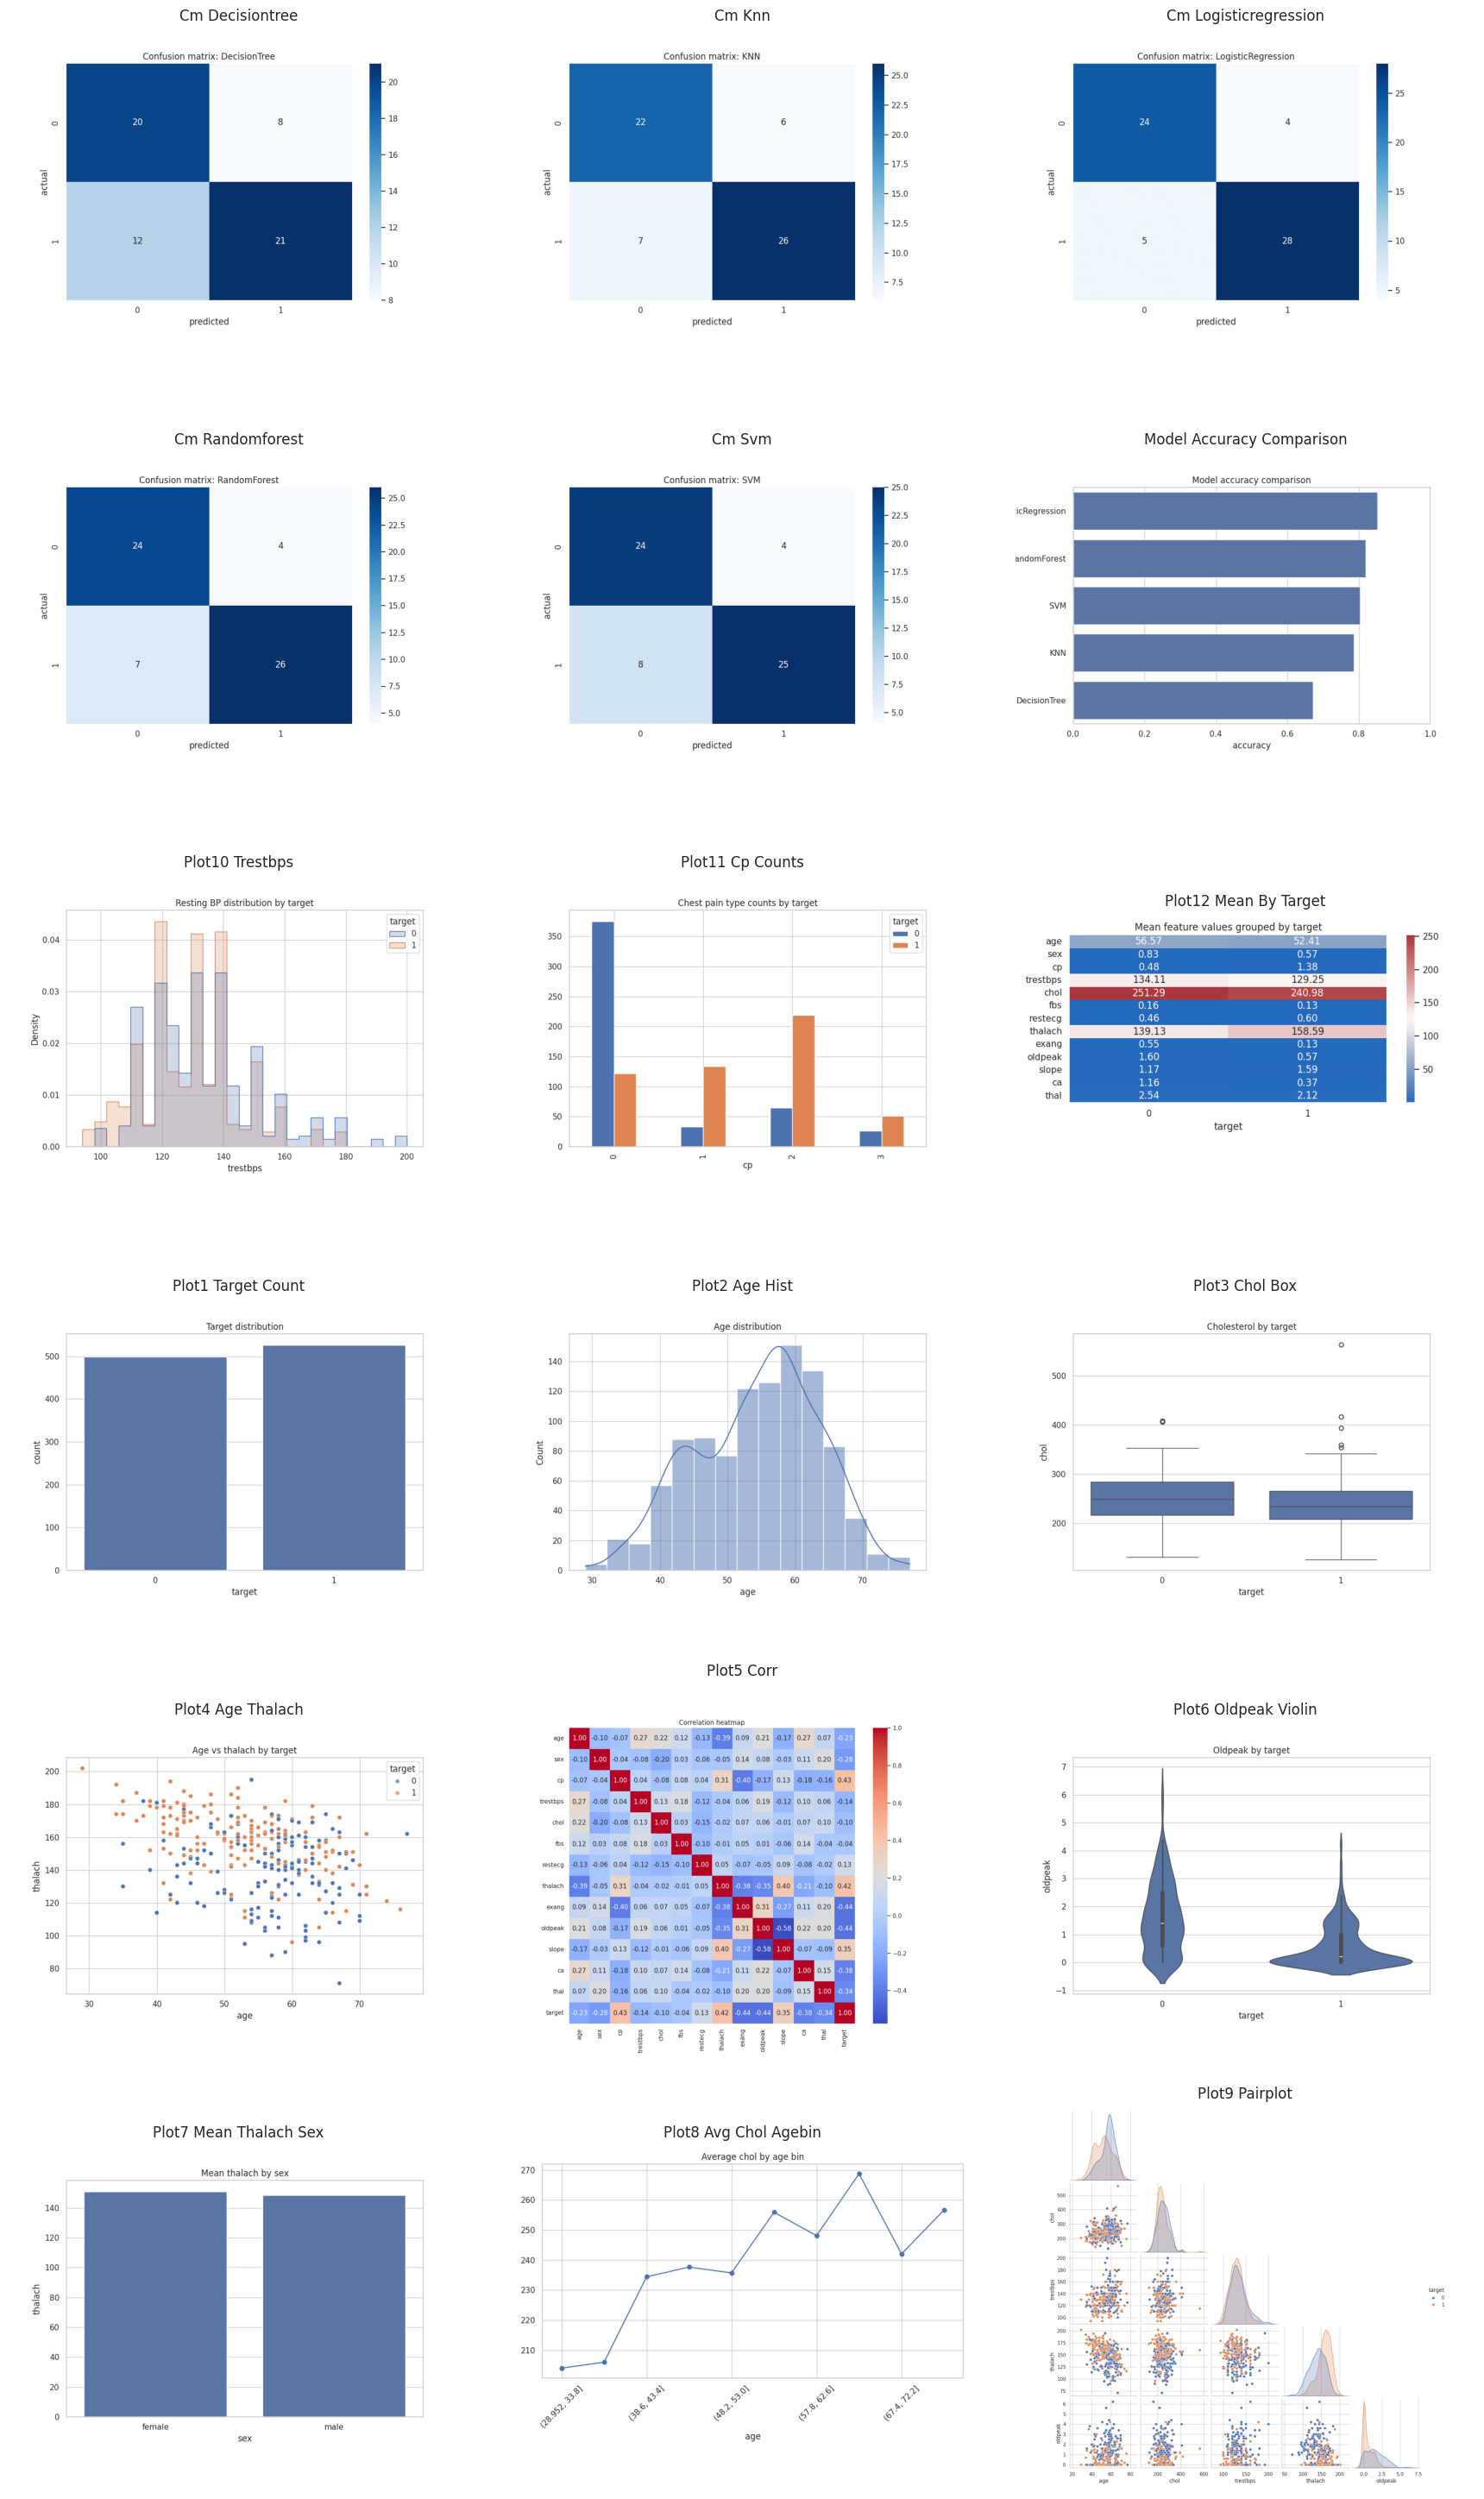

In [ ]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots_dir = "./plots"

# Verify directory exists
if not os.path.exists(plots_dir):
    print("⚠️ No plots directory found!")
else:
    image_files = sorted([f for f in os.listdir(plots_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    if not image_files:
        print("⚠️ No plot images found in the directory.")
    else:
        print(f"🖼️ Displaying {len(image_files)} plots from: {plots_dir}\n")

        # Grid size (3 columns)
        cols = 3
        rows = math.ceil(len(image_files) / cols)

        plt.figure(figsize=(18, rows * 5))
        for i, img_file in enumerate(image_files, 1):
            img_path = os.path.join(plots_dir, img_file)
            img = mpimg.imread(img_path)

            plt.subplot(rows, cols, i)
            plt.imshow(img)
            plt.title(img_file.replace(".png", "").replace("_", " ").title(), fontsize=12)
            plt.axis("off")

        plt.tight_layout(pad=3.0)
        plt.show()



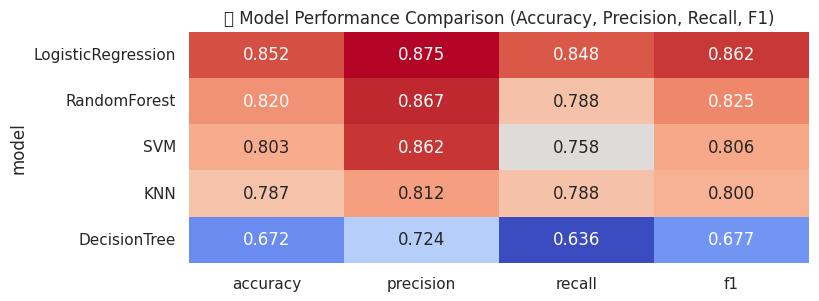

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.read_csv("model_results.csv")
plt.figure(figsize=(8,3))
sns.heatmap(results_df.set_index('model'), annot=True, fmt=".3f", cmap='coolwarm', cbar=False)
plt.title("📊 Model Performance Comparison (Accuracy, Precision, Recall, F1)")
plt.yticks(rotation=0)
plt.show()

